# Wikimedia Attention and Hype Decay

This notebook uses real Wikimedia Analytics API pageviews to measure public attention cycles. Pageviews are attention, not truth or importance.

No synthetic fallback is used.


In [1]:
from pathlib import Path
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prefer the checkout when this notebook is run inside the repository.
repo_root = Path.cwd()
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent, Path.cwd().parent.parent.parent]:
    if (candidate / "src" / "detime").exists():
        repo_root = candidate
        break
sys.path.insert(0, str(repo_root / "src"))
sys.path.insert(0, str(repo_root))

from examples.hot_trends.data import (
    HotTrendDataError,
    append_real_snapshot,
    build_arxiv_monthly_counts,
    fetch_coingecko_market_chart,
    fetch_defillama_stablecoin_chains,
    fetch_github_repo_metadata,
    fetch_github_stargazers,
    fetch_huggingface_models,
    fetch_wikipedia_pageviews,
    source_audit_table,
)
from examples.hot_trends.decomposition import (
    component_summary,
    decompose_table,
    editorial_priority,
    residual_event_table,
)
from examples.hot_trends.scoring import article_language_guardrails

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
plt.rcParams.update({"axes.grid": True})

CACHE_DIR = repo_root / "examples" / "hot_trends" / "cache"
OUTPUT_DIR = repo_root / "examples" / "hot_trends" / "outputs"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

def save_table(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    relative_path = path.relative_to(repo_root).as_posix()
    print(f"saved: {relative_path}")


## 1. Select pages and date window


In [2]:
articles = [
    "Artificial intelligence",
    "Large language model",
    "ChatGPT",
    "Bitcoin",
    "Nvidia",
    "OpenAI",
]
START = "2025-01-01"
END = "2026-05-20"
pd.DataFrame({"article": articles})


,article
0,Artificial intelligence
1,Large language model
2,ChatGPT
3,Bitcoin
4,Nvidia
5,OpenAI


## 2. Fetch real pageviews


In [3]:
frames = []
for article in articles:
    frames.append(fetch_wikipedia_pageviews(article, start=START, end=END))
views = pd.concat(frames, ignore_index=True)
views.head(20)


,date,article,views,project,source,data_quality
0,2025-01-01,Artificial intelligence,9447,en.wikipedia.org,Wikimedia Analytics API,live_public_api_no_synthetic_fallback
1,2025-01-02,Artificial intelligence,10777,en.wikipedia.org,Wikimedia Analytics API,live_public_api_no_synthetic_fallback
2,2025-01-03,Artificial intelligence,10148,en.wikipedia.org,Wikimedia Analytics API,live_public_api_no_synthetic_fallback
3,2025-01-04,Artificial intelligence,9172,en.wikipedia.org,Wikimedia Analytics API,live_public_api_no_synthetic_fallback
4,2025-01-05,Artificial intelligence,8865,en.wikipedia.org,Wikimedia Analytics API,live_public_api_no_synthetic_fallback
5,2025-01-06,Artificial intelligence,11022,en.wikipedia.org,Wikimedia Analytics API,live_public_api_no_synthetic_fallback
6,2025-01-07,Artificial intelligence,12419,en.wikipedia.org,Wikimedia Analytics API,live_public_api_no_synthetic_fallback
7,2025-01-08,Artificial intelligence,12421,en.wikipedia.org,Wikimedia Analytics API,live_public_api_no_synthetic_fallback
8,2025-01-09,Artificial intelligence,12147,en.wikipedia.org,Wikimedia Analytics API,live_public_api_no_synthetic_fallback
9,2025-01-10,Artificial intelligence,11222,en.wikipedia.org,Wikimedia Analytics API,live_public_api_no_synthetic_fallback


## 3. Audit the real pageview table


In [4]:
audit = source_audit_table(views, value_col="views", entity_col="article", time_col="date")
audit


,series,first_timestamp,last_timestamp,observations,missing_ratio,min_value,max_value
0,Artificial intelligence,2025-01-01 00:00:00,2026-05-20 00:00:00,505,0.0,6726.0,47069.0
1,Bitcoin,2025-01-01 00:00:00,2026-05-20 00:00:00,505,0.0,2241.0,18494.0
2,ChatGPT,2025-01-01 00:00:00,2026-05-20 00:00:00,505,0.0,33844.0,832465.0
3,Large language model,2025-01-01 00:00:00,2026-05-20 00:00:00,505,0.0,1965.0,11498.0
4,Nvidia,2025-01-01 00:00:00,2026-05-20 00:00:00,505,0.0,3163.0,68291.0
5,OpenAI,2025-01-01 00:00:00,2026-05-20 00:00:00,505,0.0,4652.0,53724.0


## 4. Decompose pageview attention


In [5]:
components = decompose_table(views, entity_col="article", time_col="date", value_col="views", method="MA_BASELINE", period=7, trend_window=21, transform="log1p")
summary = editorial_priority(component_summary(components, entity_col="article", time_col="date"), entity_col="article")
summary


,article,observations,first_timestamp,last_timestamp,trend_last,trend_slope_per_step,cycle_strength_proxy,residual_std,max_abs_residual_z,method,trend_slope_per_step_rank_pct,cycle_strength_proxy_rank_pct,max_abs_residual_z_rank_pct,editorial_priority_score
0,Artificial intelligence,505,2025-01-01 00:00:00,2026-05-20 00:00:00,4.882320,-0.000011,-6.502693,0.544259,55.176621,MA_BASELINE,1.000000,0.166667,0.833333,0.758333
3,Large language model,505,2025-01-01 00:00:00,2026-05-20 00:00:00,4.231900,-0.000431,-3.389617,0.470944,59.617727,MA_BASELINE,0.500000,0.333333,1.000000,0.691667
2,ChatGPT,505,2025-01-01 00:00:00,2026-05-20 00:00:00,5.828161,-0.000429,-1.903450,0.698960,46.942855,MA_BASELINE,0.666667,0.666667,0.666667,0.666667
4,Nvidia,505,2025-01-01 00:00:00,2026-05-20 00:00:00,4.882153,-0.000056,-1.019794,0.605797,23.278477,MA_BASELINE,0.833333,1.000000,0.166667,0.566667
5,OpenAI,505,2025-01-01 00:00:00,2026-05-20 00:00:00,4.726995,-0.000514,-2.325489,0.555429,40.235922,MA_BASELINE,0.333333,0.500000,0.500000,0.441667
1,Bitcoin,505,2025-01-01 00:00:00,2026-05-20 00:00:00,4.202332,-0.001413,-1.550364,0.527478,33.181356,MA_BASELINE,0.166667,0.833333,0.333333,0.375000


## Visualization: Wikimedia attention components

Top article panels reveal the transformed pageview trend and residual attention shocks.

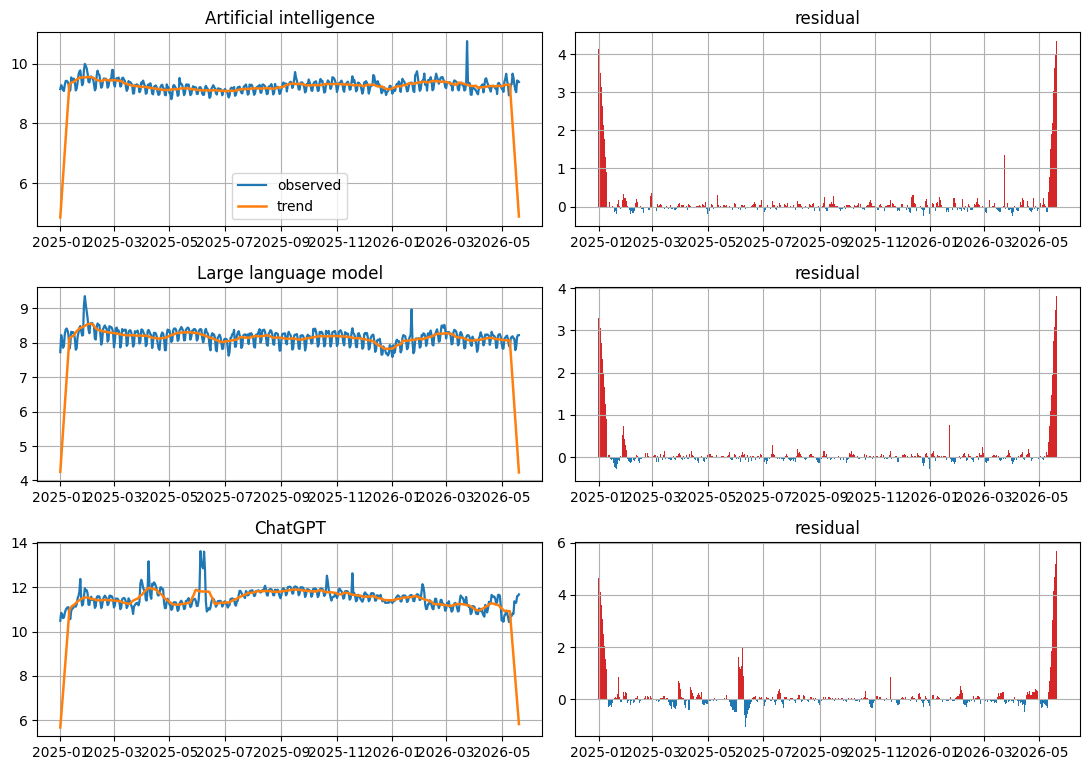

In [6]:
top_articles = summary["article"].head(3).tolist()
fig, axes = plt.subplots(len(top_articles), 2, figsize=(11, max(3.0, 2.6 * len(top_articles))), squeeze=False)
for row, article in enumerate(top_articles):
    panel = components.loc[components["article"].eq(article)].sort_values("date").copy()
    panel["date"] = pd.to_datetime(panel["date"])
    axes[row, 0].plot(panel["date"], panel["observed"], label="observed", linewidth=1.6)
    axes[row, 0].plot(panel["date"], panel["trend"], label="trend", linewidth=1.8)
    axes[row, 0].set_title(article)
    axes[row, 1].bar(panel["date"], panel["residual"], color=np.where(panel["residual"] >= 0, "tab:red", "tab:blue"), width=1.0)
    axes[row, 1].set_title("residual")
axes[0, 0].legend(loc="best")
plt.tight_layout()
plt.show()


## 5. Residual shock events


In [7]:
events = residual_event_table(components, entity_col="article", time_col="date", top_n=25)
events


,date,article,observed,trend,season,residual,residual_z,abs_residual_z,method
0,2026-05-20,Large language model,8.218787,4.231900,0.178067,3.808820,59.617727,59.617727,MA_BASELINE
1,2026-05-20,Artificial intelligence,9.388487,4.882320,0.159566,4.346601,55.176621,55.176621,MA_BASELINE
2,2026-05-19,Large language model,8.216358,4.609306,0.126721,3.480331,54.475977,54.475977,MA_BASELINE
3,2025-01-02,Large language model,8.220403,4.627593,0.113499,3.479311,54.460007,54.460007,MA_BASELINE
4,2025-01-01,Artificial intelligence,9.153558,4.850246,0.159566,4.143747,52.605795,52.605795,MA_BASELINE
5,2025-01-01,Large language model,7.724888,4.248696,0.178067,3.298125,51.623946,51.623946,MA_BASELINE
6,2026-05-19,Artificial intelligence,9.428190,5.308164,0.116739,4.003287,50.825719,50.825719,MA_BASELINE
7,2025-01-02,Artificial intelligence,9.285262,5.284128,0.078876,3.922259,49.798823,49.798823,MA_BASELINE
8,2026-05-18,Large language model,8.167919,4.994446,0.086805,3.086668,48.314061,48.314061,MA_BASELINE
9,2025-01-03,Large language model,8.076826,5.023572,0.007082,3.046172,47.680178,47.680178,MA_BASELINE


## 6. Hype-decay table

A simple decay proxy: after each article's largest residual event, count days until residual drops below half of that peak.


In [8]:
decay_rows = []
for article, sub in components.groupby("article"):
    sub = sub.sort_values("date").copy()
    rz = (sub["residual"] - sub["residual"].median()).abs()
    peak_idx = int(rz.idxmax())
    peak_date = pd.to_datetime(sub.loc[peak_idx, "date"])
    peak = float(rz.loc[peak_idx])
    after = sub.loc[peak_idx:].copy()
    after_rz = (after["residual"] - sub["residual"].median()).abs()
    below = after.loc[after_rz <= 0.5 * peak]
    half_life_days = None if below.empty else int((pd.to_datetime(below["date"].iloc[0]) - peak_date).days)
    decay_rows.append({"article": article, "peak_date": str(peak_date.date()), "peak_residual_abs": peak, "attention_half_life_days": half_life_days})
decay = pd.DataFrame(decay_rows).sort_values("peak_residual_abs", ascending=False)
decay


,article,peak_date,peak_residual_abs,attention_half_life_days
2,ChatGPT,2026-05-20,5.676558,NaN
5,OpenAI,2026-05-20,4.468527,NaN
0,Artificial intelligence,2026-05-20,4.353788,NaN
4,Nvidia,2026-05-20,4.332644,NaN
1,Bitcoin,2025-01-01,4.162031,6.0
3,Large language model,2026-05-20,3.808767,NaN


## Visualization: hype decay half-life

The bar chart exposes which attention spikes decayed quickly and which stayed elevated or remain unresolved.

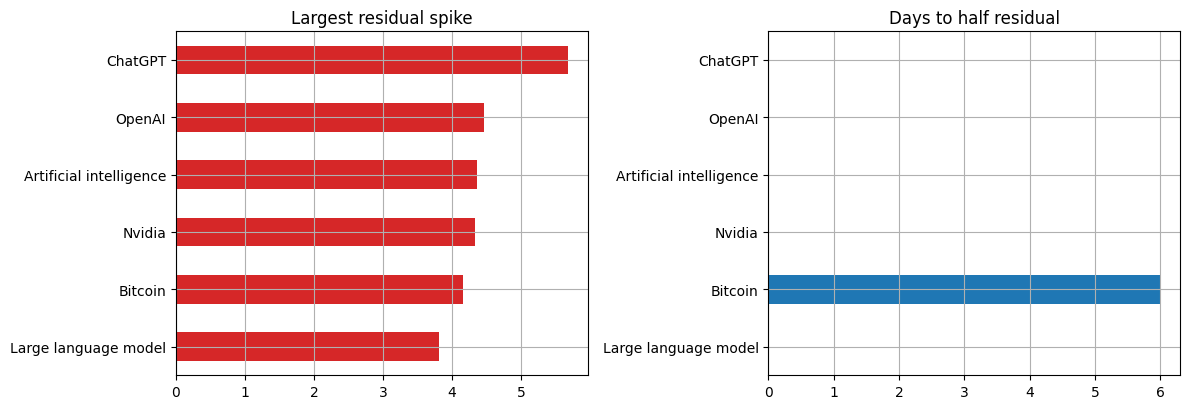

In [9]:
decay_plot = decay.copy()
decay_plot["attention_half_life_days"] = pd.to_numeric(decay_plot["attention_half_life_days"], errors="coerce")
decay_plot = decay_plot.sort_values("peak_residual_abs")
fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
decay_plot.plot(kind="barh", x="article", y="peak_residual_abs", ax=axes[0], color="tab:red", legend=False, title="Largest residual spike")
decay_plot.assign(attention_half_life_days=decay_plot["attention_half_life_days"].fillna(0)).plot(kind="barh", x="article", y="attention_half_life_days", ax=axes[1], color="tab:blue", legend=False, title="Days to half residual")
axes[0].set_ylabel("")
axes[1].set_ylabel("")
plt.tight_layout()
plt.show()


In [10]:
save_table(audit, "05_wikipedia_attention_audit")
save_table(summary, "05_wikipedia_attention_summary")
save_table(events, "05_wikipedia_attention_events")
save_table(decay, "05_wikipedia_hype_decay")
save_table(article_language_guardrails(), "05_wikipedia_guardrails")


saved: examples/hot_trends/outputs/05_wikipedia_attention_audit.csv
saved: examples/hot_trends/outputs/05_wikipedia_attention_summary.csv
saved: examples/hot_trends/outputs/05_wikipedia_attention_events.csv
saved: examples/hot_trends/outputs/05_wikipedia_hype_decay.csv
saved: examples/hot_trends/outputs/05_wikipedia_guardrails.csv
